# Generate an image from two image URLs with Gemini

This notebook downloads two public images into memory, combines them with a text prompt, and asks `gemini-3.1-flash-image` to generate a new image. The inputs and output are displayed inline and are never saved to disk.

## 1. Sync project dependencies

This repository uses `uv`. Run this cell, then select the project's `.venv` as the notebook kernel if imports are unavailable.

In [188]:
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent

assert (project_root / "pyproject.toml").exists(), (
    "Run this notebook from the project root or notebooks folder."
)

!UV_CACHE_DIR="{project_root / '.uv-cache'}" uv sync --project "{project_root}"

print(f"Project environment: {project_root / '.venv'}")
print("If imports fail, switch this notebook to the .venv kernel and rerun the cells.")

342348.68s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Resolved 78 packages in 35ms
Checked 75 packages in 28ms
Project environment: /Users/aman/Work/ai/guide/.venv
If imports fail, switch this notebook to the .venv kernel and rerun the cells.


In [189]:
from pydantic import BaseModel

## 2. Configure the Gemini API key

The key is read from `GEMINI_API_KEY` when available. Otherwise, the notebook prompts for it securely without displaying the value.

In [190]:
import getpass
import os

if not os.environ.get("GEMINI_API_KEY"):
    api_key = getpass.getpass("Enter your Gemini API key: ").strip()
    if not api_key:
        raise ValueError("A Gemini API key is required.")
    os.environ["GEMINI_API_KEY"] = api_key

## 3. Set the two image URLs and prompt

Replace both example URLs with direct, publicly accessible image URLs. The server must return an `image/*` content type.

In [191]:
IMAGE_1_URL = "https://randomuser.me/api/portraits/women/8.jpg"
IMAGE_2_URL = "https://media-cdn.june.date/touchable/production/tarot-cards/final-decks/the-bloom-collection/THE_EMPRESS.png"
PROMPT = """
Image requirement:
highly detailed illustrated tarot card, soft storybook illustration style, hand-painted look, pastel color palette, spring floral environment,
delicate textures, smooth shading, whimsical magical atmosphere

ornate decorative tarot frame, elegant gold floral border, intricate linework, symmetrical art nouveau design

soft glowing particles, dreamy lighting, painterly rendering

same person as reference image, identical face, preserve facial features exactly, same eyes, nose, lips, natural skin texture, clean skin

adapt clothing, styling, and presence to match the person naturally (do not force gender-specific outfits unless defined in the scene)

center composition, tarot card layout

top title area with elegant serif tarot typography, Roman numeral above the title, same position, same font style, same size, same spacing
across all cards, only change the title text according to the card name

clean balanced margins, no distortion of frame

create a scene, pose, and environment based on the tarot card meaning, while keeping the same illustration style, frame, and character identity

ensure variation in pose, camera angle, and composition for each card while maintaining overall style consistency

Your task is to generate the following card:-
TITLE: NINE OF WANDS
 ROMAN NUMERAL: IX
 Person standing in guard.
 There should be exactly 9 wands in the output image.
"""

## 4. Download and preview the inputs

The helper follows redirects, rejects HTTP errors and non-image responses, and keeps the downloaded bytes in memory.

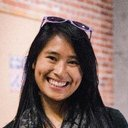

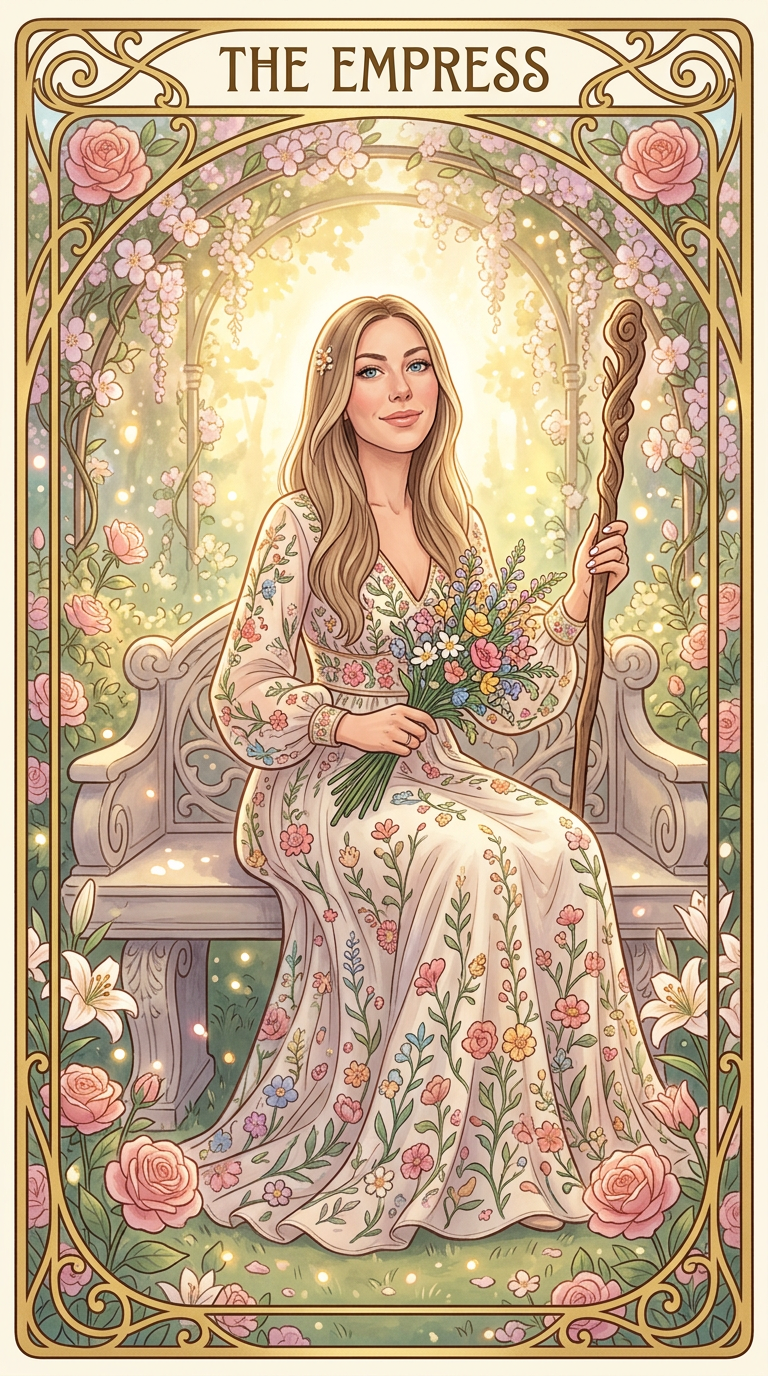

In [192]:
from dataclasses import dataclass
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen

from IPython.display import Image as DisplayImage
from IPython.display import display


@dataclass(frozen=True)
class DownloadedImage:
    data: bytes
    mime_type: str


def download_image(url: str, timeout: float = 30.0) -> DownloadedImage:
    if not url.lower().startswith(("http://", "https://")):
        raise ValueError(f"Image URL must use http or https: {url!r}")

    request = Request(url, headers={"User-Agent": "image-generation-notebook/1.0"})
    try:
        with urlopen(request, timeout=timeout) as response:
            mime_type = response.headers.get_content_type().lower()
            if not mime_type.startswith("image/"):
                raise ValueError(
                    f"URL did not return an image (Content-Type: {mime_type!r}): {url}"
                )
            data = response.read()
    except HTTPError as exc:
        raise RuntimeError(f"Image request failed with HTTP {exc.code}: {url}") from exc
    except URLError as exc:
        raise RuntimeError(f"Could not download image from {url}: {exc.reason}") from exc

    if not data:
        raise ValueError(f"Image response was empty: {url}")

    return DownloadedImage(data=data, mime_type=mime_type)


input_image_1 = download_image(IMAGE_1_URL)
input_image_2 = download_image(IMAGE_2_URL)

display(DisplayImage(data=input_image_1.data, width=300))
display(DisplayImage(data=input_image_2.data, width=300))

## 5. Generate and display the new image

This cell sends the prompt and both base64-encoded images to Gemini. The returned image is decoded and displayed directly from memory.

Gemini interaction completed successfully.


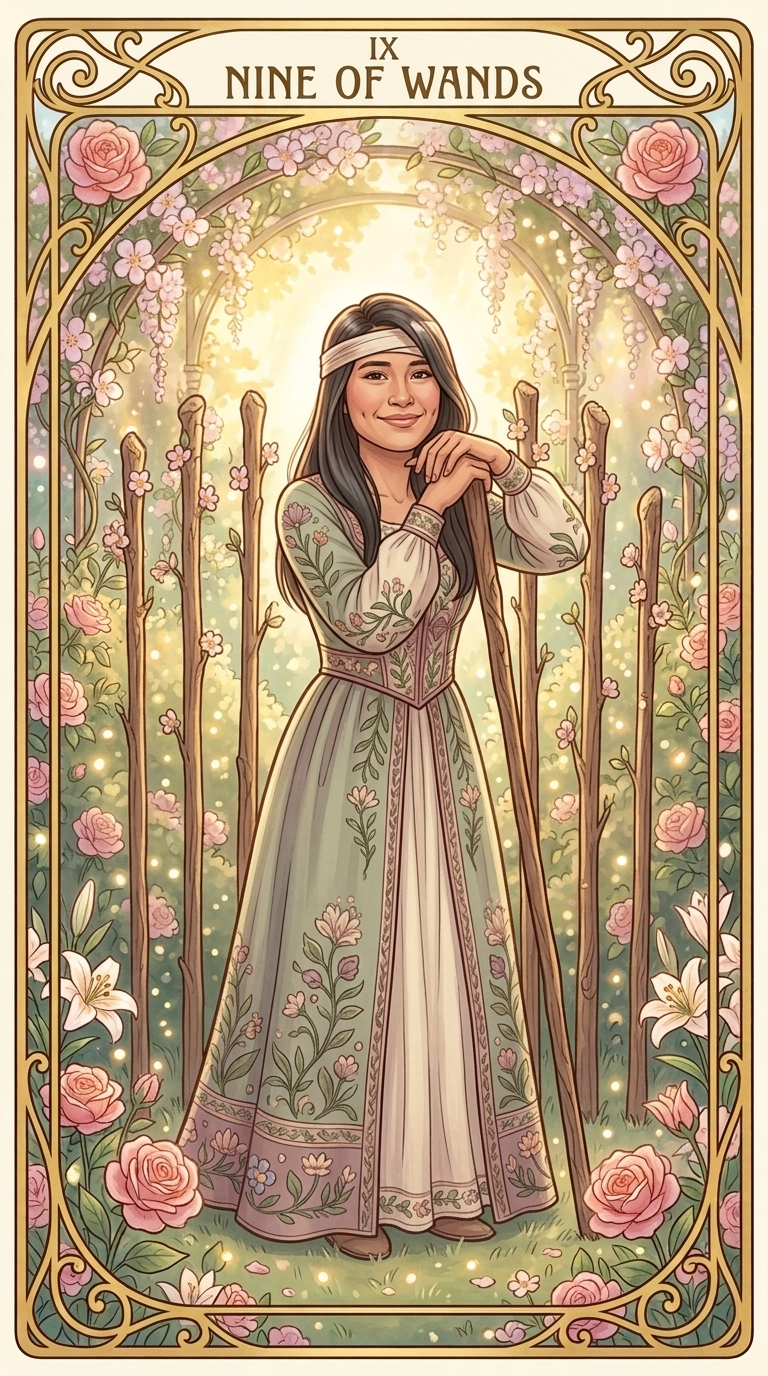

In [193]:
import base64

from google import genai

MODEL = "gemini-3.1-flash-image-preview"
aspect_ratio="9:16"

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
interaction = None

try: 
    interaction = client.interactions.create(
        model=MODEL,
        input=[
            {"type": "text", "text": PROMPT},
            {
                "type": "image",
                "data": base64.b64encode(input_image_1.data).decode("ascii"),
                "mime_type": input_image_1.mime_type,
            },
            {
                "type": "image",
                "data": base64.b64encode(input_image_2.data).decode("ascii"),
                "mime_type": input_image_2.mime_type,
            },
        ],
        response_format={"type": "image", "aspect_ratio": aspect_ratio, "mime_type": "image/jpeg"},
    )

    print("Gemini interaction completed successfully.")

    if interaction.output_image is None or not interaction.output_image.data:
        detail = interaction.output_text or "No explanatory text was returned."
        raise RuntimeError(f"Gemini did not return an image. {detail}")

    generated_image_data = interaction.output_image.data
    generated_image_mime_type = interaction.output_image.mime_type

    generated_image = base64.b64decode(generated_image_data, validate=True)
    display(DisplayImage(data=generated_image, width=300))
except Exception as e:
    print(f"Error during image generation: {e}")
    print(interaction)

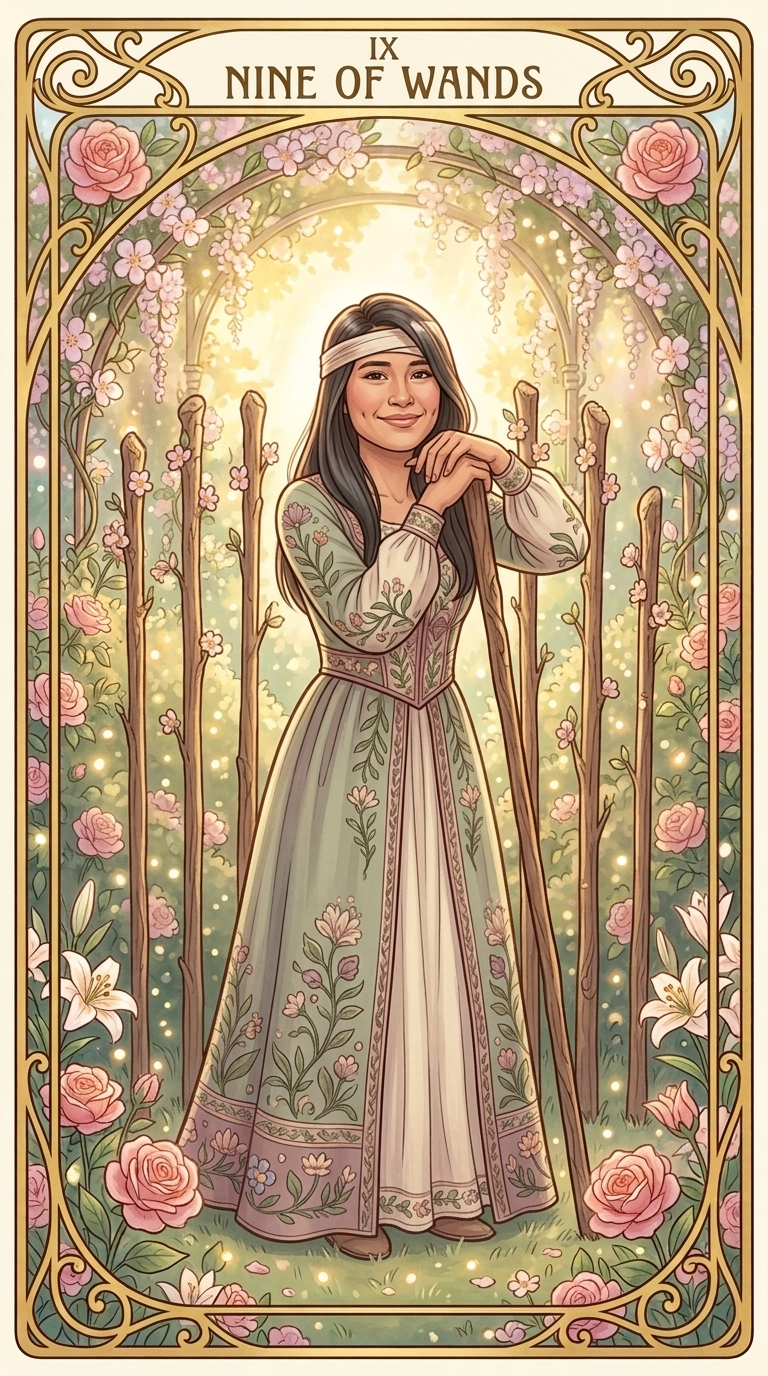

Model: gemini-3.1-flash-lite
{
  "count_of_wands": 8,
  "feedback": "There are 8 wooden wands visible in the image. One is held by the person, while the others form a background fence-like structure."
}
----------------------------------------
Model: gemini-3.5-flash-lite
{
  "count_of_wands": 9,
  "feedback": "There are 9 wands depicted in the image: 5 standing upright on the left side, 2 leaning diagonally held by the woman, 1 standing vertically behind the woman on the right, and 1 standing upright on the far right."
}
----------------------------------------
Model: gemini-3.8-flash
{
  "count_of_wands": 7,
  "feedback": "Despite the card being titled 'Nine of Wands', there are only 7 wands present in the illustration: 3 standing to the left of the woman, 1 held wand she leans on, and 3 standing to her right."
}
----------------------------------------


In [194]:
generated_image_data = interaction.output_image.data
generated_image_mime_type = interaction.output_image.mime_type

class EvaluationFeedback(BaseModel):
  count_of_wands: int
  feedback: str

display(DisplayImage(data=generated_image, width=300))

MODELS = [
  "gemini-3.1-flash-lite",
  "gemini-3.5-flash-lite",
  "gemini-3.8-flash"
]

for model in MODELS:
    evaluation = client.interactions.create(
        model=model,
        input=[
            {"type": "text", "text": "Count the number of wands in the given image. Ignore any numbers given in the image."},
            {
                "type": "image",
                "data": generated_image_data,
                "mime_type": generated_image_mime_type
            }
        ],
        response_format={"type": "text", "mime_type": "application/json", "schema": EvaluationFeedback.model_json_schema() }
    )

    print(f"Model: {model}")
    print(evaluation.output_text)
    print("-"*40)

# END